In [7]:
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import fcluster, dendrogram, linkage
from scipy.spatial.distance import squareform
import os
import re

In [8]:
curr_dir = os.getcwd()
print(curr_dir)
base_dir = os.path.dirname(curr_dir)
arena_data_dir = os.path.join(base_dir, '3D_Data')
arena_visualizations_dir = os.path.join( base_dir , '3D_Visualizations')

d:\from desktop\Hadents Folder\Visualization\AccelCluster-Visualizations


In [9]:
# CHANGE HERE: Path to your mat file
#filename = r"X:\3darena_behavior\wildtype\wildtype_062425\011725_9\All_Arenas_Accel\Results\test1\session_1_out.mat"
filename = r"C:\Users\gangliagurdian\Desktop\Calan\011625_4\session_1_out.mat"


In [5]:
with h5py.File(filename, 'r') as file:
    if 'Clusters' in file:
        clusters_group = file['Clusters']
        if 'sim' in clusters_group:
            sim_data = clusters_group['sim'][:]
            sim_matrix_data = pd.DataFrame(sim_data)

        if 'idx' in clusters_group:
            idx_data = clusters_group['idx'][:]
            clusters_data = pd.DataFrame(idx_data).transpose()

In [6]:
# CHANGE HERE: Ensure that your recordings are proportionate to the thresholds below. 
# Eg. If you have 3 recordings that are each 2 hours long, each experiment type will have 1/3 of the data. 
# Assign experiment types by proportions:
N = clusters_data.shape[0]
threshold_week1 = int((1/3) * N)
threshold_week3 = threshold_week1 + int((1/3) * N)

# Week 1: 0 to threshold_week1 = 33.33% of the data
clusters_data_week1 = clusters_data.iloc[:threshold_week1]
clusters_data_sorted_week1 = clusters_data_week1.sort_values(by=0)
clusters_data_sorted_week1[0] = clusters_data_sorted_week1[0].astype(int)

# Week 2: threshold_week1 to threshold_week3 = 33.33% of the data
clusters_data_week3 = clusters_data.iloc[threshold_week1:threshold_week3]
clusters_data_sorted_week3 = clusters_data_week3.sort_values(by=0)
clusters_data_sorted_week3[0] = clusters_data_sorted_week3[0].astype(int)

# Week 6: threshold_week3 to end = 33.33% of the data
clusters_data_week6 = clusters_data.iloc[threshold_week3:]
clusters_data_sorted_week6 = clusters_data_week6.sort_values(by=0)
clusters_data_sorted_week6[0] = clusters_data_sorted_week6[0].astype(int)

In [10]:
clusters_data['ExperimentType'] = ['week1' if i < threshold_week1 else 'week3' if i < threshold_week3 else 'week6' for i in range(N)]
clusters_data = clusters_data.rename(columns={0: 'cluster'})

In [11]:
clusters_data_sorted = clusters_data.sort_values(by='cluster')
clusters_data_sorted['cluster'] = clusters_data_sorted['cluster'].astype( int )

In [12]:
def plot_similarity_matrix(sim_matrix, title, xlabel, ylabel, colorbar_threshold=-0.3, save=False, path=None):
    data_array = sim_matrix.to_numpy()
    cluster_labels = sim_matrix.index.astype(str)  
    
    plt.figure(figsize=(12, 9))
    im = plt.imshow(data_array, cmap='Blues', interpolation='nearest', vmin=colorbar_threshold, vmax=0)
    plt.colorbar(im)
    plt.clim(colorbar_threshold, 0)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.xticks(ticks=np.arange(len(cluster_labels)), labels=cluster_labels, rotation=90)
    plt.yticks(ticks=np.arange(len(cluster_labels)), labels=cluster_labels)

    if save:
        if path is None:
            safe_title = re.sub(r'[^\w\-_. ]', '_', title).replace(' ', '_')
            path = f"{safe_title}.eps"

        eps_dir = os.path.dirname(path)
        if eps_dir:
            os.makedirs(eps_dir, exist_ok=True)

        base_filename = os.path.splitext(os.path.basename(path))[0]
        eps_path = os.path.join(eps_dir, base_filename + '.eps')
        plt.savefig(eps_path, format='eps', bbox_inches='tight')
        print(f"EPS saved to: {eps_path}")

        parent_dir = os.path.dirname(eps_dir)
        png_dir = os.path.join(parent_dir, 'png')
        os.makedirs(png_dir, exist_ok=True)

        png_path = os.path.join(png_dir, base_filename + '.png')
        plt.savefig(png_path, format='png', dpi=300, bbox_inches='tight')
        print(f"PNG saved to: {png_path}")

    plt.tight_layout()
    plt.show()

In [13]:
sorted_indices = clusters_data_sorted.index
reordered_matrix = sim_matrix_data.loc[sorted_indices, sorted_indices]

In [14]:
cluster_counts = clusters_data_sorted['cluster'].value_counts().reset_index()
cluster_counts.columns = ['cluster', 'count']
cluster_counts = cluster_counts.sort_values(by='cluster')

In [15]:
# Computes a condensed version of original matrix by averaging together the rows and columns where the cluster label is the same

clusters = cluster_counts['cluster']
counts = cluster_counts['count'].values

final_matrix = np.zeros((len(clusters), len(clusters)))

# Compute averages for each cluster pair
for i, cluster_i in enumerate(clusters):
    for j, cluster_j in enumerate(clusters):
        # Get the indices for rows and columns in the original matrix for the respective clusters
        rows_i = clusters_data_sorted[clusters_data_sorted['cluster'] == cluster_i].index
        rows_j = clusters_data_sorted[clusters_data_sorted['cluster'] == cluster_j].index
        
        # Compute the average of the submatrix
        submatrix = reordered_matrix.loc[rows_i, rows_j]
        final_matrix[i, j] = submatrix.values.mean()

final_matrix_df = pd.DataFrame(final_matrix, index=clusters, columns=clusters)


In [16]:
def create_dendrogram( similarity_matrix , max_height = 0.1 , save = False , path = None ):
    final_matrix_df = (similarity_matrix + similarity_matrix.T) / 2
    final_matrix_df = final_matrix_df.abs()
    np.fill_diagonal(final_matrix_df.values, 0)
    condensed_matrix = squareform(final_matrix_df)
    linkage_matrix = linkage(condensed_matrix, method='average')

    plt.figure(figsize=(10, 7))
    labels = [str(i + 1) for i in range(similarity_matrix.shape[0])]
    dendrogram(linkage_matrix, labels=labels, leaf_rotation=90, leaf_font_size=8)
    plt.title("Dendogram")
    plt.xlabel("Clusters")
    plt.ylabel("Distance")
    plt.ylim(0, max_height)
    plt.tight_layout()

    if save:
        if path is None:
            safe_title = re.sub(r'[^\w\-_. ]', '_', title).replace(' ', '_')
            path = f"{safe_title}.eps"

        eps_dir = os.path.dirname(path)
        if eps_dir:
            os.makedirs(eps_dir, exist_ok=True)

        base_filename = os.path.splitext(os.path.basename(path))[0]
        eps_path = os.path.join(eps_dir, base_filename + '.eps')
        plt.savefig(eps_path, format='eps', bbox_inches='tight')
        print(f"EPS saved to: {eps_path}")

        parent_dir = os.path.dirname(eps_dir)
        png_dir = os.path.join(parent_dir, 'png')
        os.makedirs(png_dir, exist_ok=True)

        png_path = os.path.join(png_dir, base_filename + '.png')
        plt.savefig(png_path, format='png', dpi=300, bbox_inches='tight')
        print(f"PNG saved to: {png_path}")


    plt.show()

    return linkage_matrix

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\gangliagurdian\AppData\Local\Temp\ipykernel_41080\119956907.py:2: SyntaxWarning: invalid escape sequence '\d'
  save_path = os.path.join( arena_visualizations_dir , 'Control\dendograms\eps\dendrogram.eps')


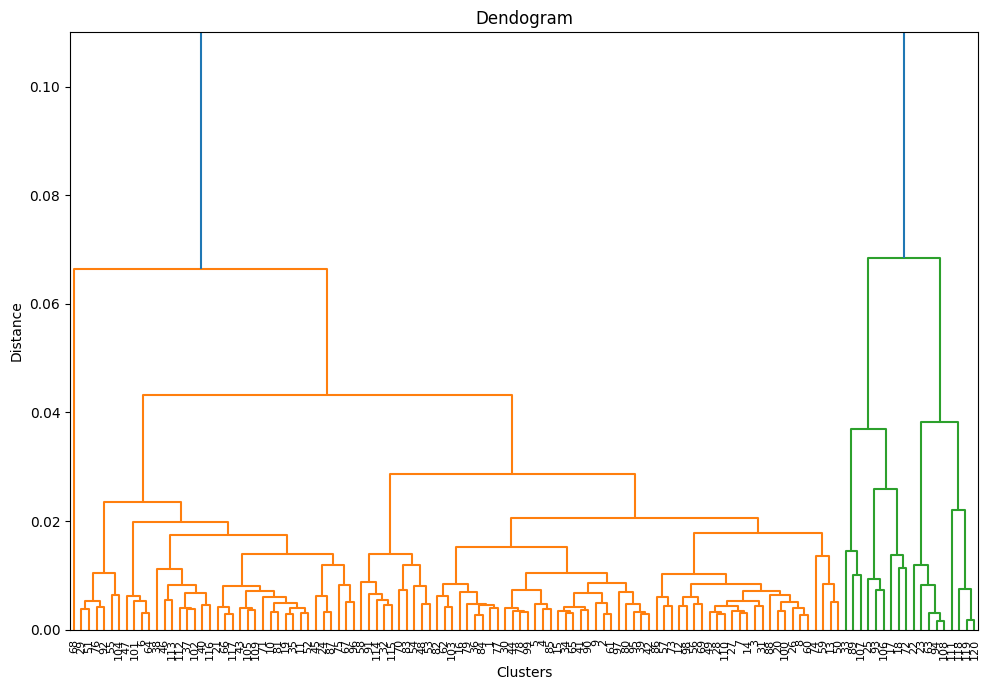

In [17]:
# CHANGE HERE: Path to your output AND title of your graph
save_path = os.path.join( arena_visualizations_dir , 'Control\dendograms\eps\dendrogram.eps')
full_linkage_matrix = create_dendrogram( final_matrix_df , max_height = 0.11 , save = False, path = save_path)

In [18]:
def plot_dendrogram_with_threshold_line(linkage_matrix , threshold, save = False , path = None ):
    plt.figure(figsize=(12, 7))
    labels = [str(i + 1) for i in range(final_matrix_df.shape[0])]
    dendrogram(linkage_matrix, labels = labels, leaf_rotation=90, leaf_font_size=8)
    plt.axhline(y=threshold, color='r', linestyle='--')  # Draw red line at threshold
    plt.title("Dendrogram with Threshold Line")
    plt.xlabel("Clusters")
    plt.ylabel("Distance")
    
    if save:
        if path is None:
            safe_title = re.sub(r'[^\w\-_. ]', '_', title).replace(' ', '_')
            path = f"{safe_title}.eps"

        eps_dir = os.path.dirname(path)
        if eps_dir:
            os.makedirs(eps_dir, exist_ok=True)

        base_filename = os.path.splitext(os.path.basename(path))[0]
        eps_path = os.path.join(eps_dir, base_filename + '.eps')
        plt.savefig(eps_path, format='eps', bbox_inches='tight')
        print(f"EPS saved to: {eps_path}")

        parent_dir = os.path.dirname(eps_dir)
        png_dir = os.path.join(parent_dir, 'png')
        os.makedirs(png_dir, exist_ok=True)

        png_path = os.path.join(png_dir, base_filename + '.png')
        plt.savefig(png_path, format='png', dpi=300, bbox_inches='tight')
        print(f"PNG saved to: {png_path}")
        
    plt.show()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\gangliagurdian\AppData\Local\Temp\ipykernel_41080\1593837314.py:2: SyntaxWarning: invalid escape sequence '\d'
  save_path = os.path.join( arena_visualizations_dir , 'Control\dendograms\eps\dendrogram_threshold.eps')


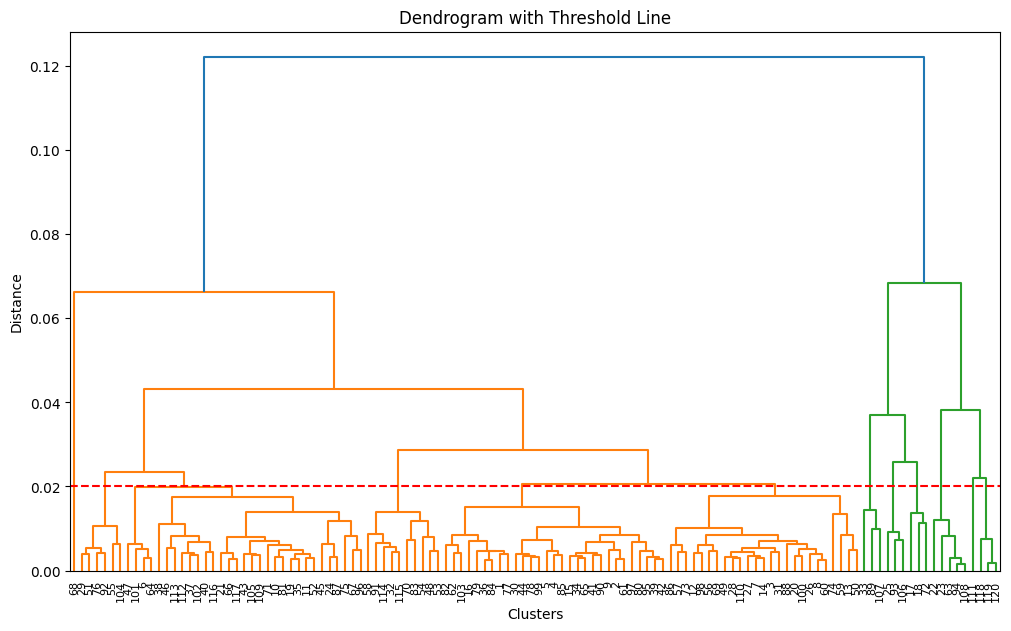

In [19]:
# CHANGE HERE: Path to your output AND desired threshold
save_path = os.path.join( arena_visualizations_dir , 'Control\dendograms\eps\dendrogram_threshold.eps')
plot_dendrogram_with_threshold_line( full_linkage_matrix , threshold=0.02 , save = False, path = save_path)

In [20]:
# Figures out which clusters should be grouped together based on a given threshold
def find_cluster_groups( linkage_matrix , sim_matrix , threshold):
    cluster_labels = fcluster(linkage_matrix, threshold, criterion='distance')
    cluster_groups_df = pd.DataFrame({'Cluster': sim_matrix.index - 1, 'Group': cluster_labels})
    cluster_groups_df['Cluster'] = cluster_groups_df['Cluster'] + 1
    clusters_groups_sorted = cluster_groups_df.sort_values(by='Group')
    return clusters_groups_sorted

In [21]:
# CHANGE HERE: Name of your csv file output AND desired threshold
clusters_groups_sorted = find_cluster_groups( full_linkage_matrix , final_matrix_df , threshold=0.02 )
clusters_groups_sorted
#clusters_groups_sorted.to_csv(os.path.join( arena_data_dir , 'groupedClusters_lc.csv') ) 
arena_data_dir = r"C:\Users\gangliagurdian\Desktop\Calan\new"

clusters_groups_sorted.to_csv(
    os.path.join(arena_data_dir, "groupedClusters_011625_4lc.csv"),
    index=False
)